A **Convolutional Neural Network (CNN)** is a specialized type of artificial neural network primarily used for analyzing visual imagery. They are a powerful tool in deep learning and have been instrumental in significant advancements in computer vision tasks like image classification, object detection, and segmentation.

Here's a breakdown of key concepts:

### 1. Convolutional Layer
This is the core building block of a CNN. It performs a **convolution operation** on the input data. Imagine a small window (called a **filter** or **kernel**) sliding over the input image. At each position, it performs element-wise multiplication between the filter and the underlying pixel values, then sums them up to produce a single output pixel. This output pixel becomes part of a **feature map**.

*   **Filters/Kernels:** These are small matrices of weights that learn to detect specific features (e.g., edges, textures, patterns) in the input image.
*   **Feature Maps:** The output of a convolutional layer, representing the detected features at different locations in the input.
*   **Stride:** The number of pixels the filter shifts over the input at each step. A larger stride reduces the size of the feature map.
*   **Padding:** Adding extra pixels (usually zeros) around the border of the input image to control the spatial size of the output feature map and prevent information loss at the edges.

### 2. Activation Function (ReLU)
After each convolutional operation, an activation function is applied. The most common one is the **Rectified Linear Unit (ReLU)**. It introduces non-linearity into the model, allowing it to learn more complex patterns. ReLU simply outputs the input if it's positive, and zero otherwise (`f(x) = max(0, x)`).

### 3. Pooling Layer (Downsampling)
Pooling layers are used to reduce the spatial dimensions (width and height) of the feature maps, thereby reducing the number of parameters and computational cost. This also helps to make the detected features more robust to small shifts or distortions in the input.

*   **Max Pooling:** The most common type, it takes the maximum value from a small rectangular region in the feature map.
*   **Average Pooling:** Takes the average value from a region.

### 4. Fully Connected Layer
After several convolutional and pooling layers, the high-level features extracted by these layers are flattened into a single vector. This vector is then fed into one or more **fully connected layers** (standard neural network layers). These layers learn non-linear combinations of these features and are responsible for the final classification or regression task.

### 5. Output Layer
The final fully connected layer typically uses an activation function like **softmax** (for multi-class classification) or **sigmoid** (for binary classification) to output probabilities for each class.

### How CNNs Work Intuitively
CNNs work by progressively extracting more abstract and complex features from the input data. Early layers might detect simple features like edges or corners. Subsequent layers combine these simple features to detect more complex patterns, such as shapes, textures, or parts of objects. The fully connected layers then use these high-level features to make a final prediction.

This hierarchical feature extraction makes CNNs highly effective for tasks involving spatial data like images.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
train=pd.read_csv("/content/mnist_train.csv")
print(train.shape)
train.head()

(60000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test=pd.read_csv("/content/mnist_test.csv")
print(test.shape)
test.head()

(10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y_train=train['label']
x_train=train.drop(labels=['label'], axis=1)

,count
label,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


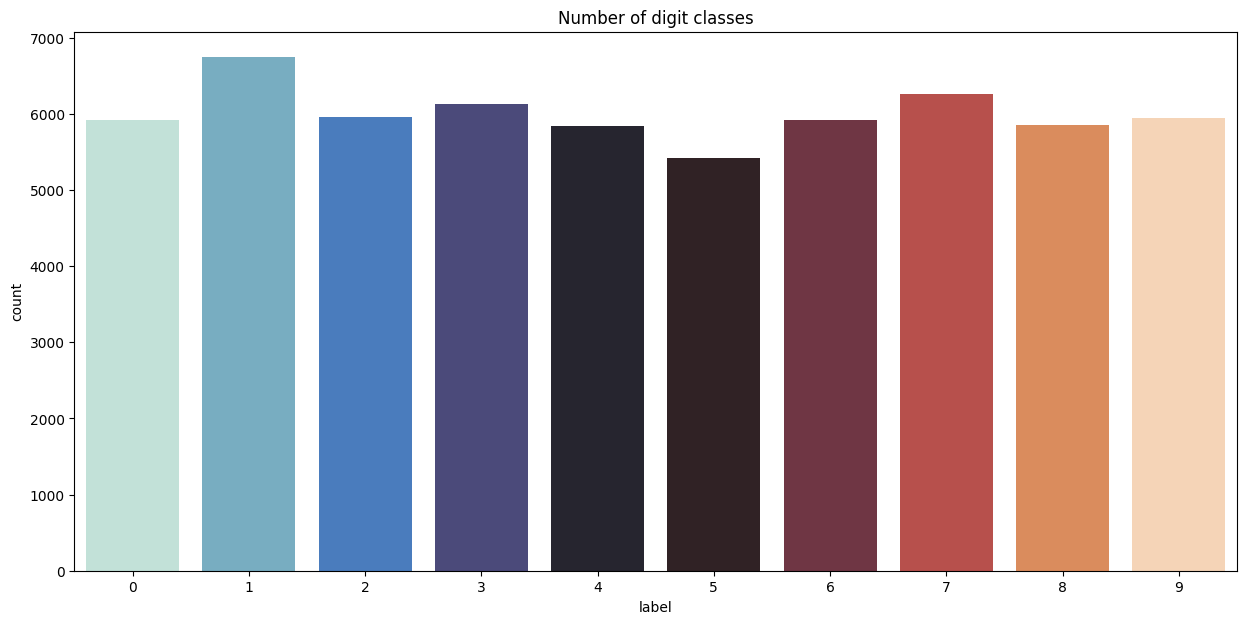

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,7))
grid=sns.countplot(x=y_train, palette='icefire',hue= y_train,legend=False)
plt.title('Number of digit classes')
y_train.value_counts()

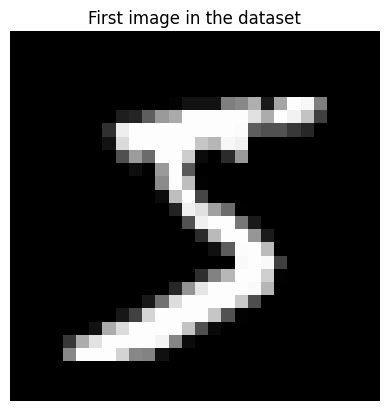

In [ ]:
img=x_train.iloc[0].to_numpy()
img=img.reshape((28,28))
plt.imshow(img, cmap='gray')
plt.title("First image in the dataset")
plt.axis('off')
plt.show()

In [ ]:
x_train=x_train/255.0
test=test/255.0
print(x_train.shape)
print(test.shape)

(60000, 784)
(10000, 785)


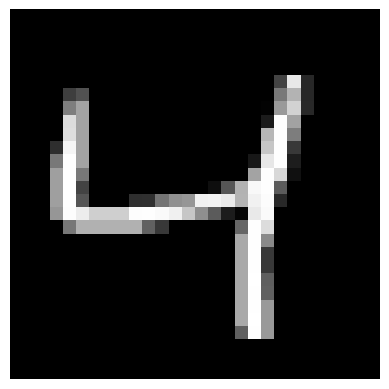

In [ ]:
image = x_train.iloc[2].values.reshape(28, 28)
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model=Sequential()
model.add(Conv2D(filters=8,kernel_size=(5,5),padding="Same",activation="relu",input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

In [ ]:
model.add(Flatten())
model.add(Dense(256,activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(10,activation="softmax"))

In [ ]:
optimizer=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
epochs=10
batch_size=250

In [ ]:
import numpy as np

x_train = x_train.to_numpy()   # or x_train.values
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)

datagen.fit(x_train_reshaped)

In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # dimesion reduction
        rotation_range=5,  # randomly rotate images in the range 5 degrees
        zoom_range = 0.1, # Randomly zoom image 10%
        width_shift_range=0.1,  # randomly shift images horizontally 10%
        height_shift_range=0.1,  # randomly shift images vertically 10%
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)
# randomly flip images
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
datagen.fit(x_train_reshaped)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes=10)

# Split the preprocessed data into training and validation sets
# using x_train_reshaped (4D image data) and y_train_cat (one-hot encoded labels)
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_reshaped, y_train_cat, test_size=0.1, random_state=42
)

history = model.fit(datagen.flow(x_train_split, y_train_split, batch_size=batch_size),
                              epochs = epochs,
                              validation_data = (x_val_split, y_val_split),
                              steps_per_epoch=x_train_split.shape[0] // batch_size)

Epoch 1/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - accuracy: 0.7832 - loss: 0.6930 - val_accuracy: 0.9593 - val_loss: 0.1419
Epoch 2/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - accuracy: 0.9211 - loss: 0.2578 - val_accuracy: 0.9762 - val_loss: 0.0858
Epoch 3/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.9386 - loss: 0.2003 - val_accuracy: 0.9800 - val_loss: 0.0719
Epoch 4/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 38s 175ms/step - accuracy: 0.9489 - loss: 0.1644 - val_accuracy: 0.9810 - val_loss: 0.0609
Epoch 5/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 36s 167ms/step - accuracy: 0.9549 - loss: 0.1457 - val_accuracy: 0.9857 - val_loss: 0.0549
Epoch 6/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 38s 174ms/step - accuracy: 0.9595 - loss: 0.1321 - val_accuracy: 0.9847 - val_loss: 0.0503
Epoch 7/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 37s 173ms/step - accuracy: 0.9620 - loss: 0.1244 - val_accuracy: 0.9858 - val_loss: 0.0467
Epoch 8/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.9649 - loss: 0